In [1]:
# setup
import sys

sys.path.insert(0, '...')

from src.config import load_parts_by_name, load_resource_lookup, load_part_lists
from src.genetic_algorithm import run_ga
from src.plots import plot_run
from datetime import datetime

parts_by_name = load_parts_by_name()
resource_lookup = load_resource_lookup()
pods, tanks, engines, decouplers = load_part_lists(parts_by_name)

In [2]:
# run
run_dir = f"../data/runs/run_{datetime.now().strftime('%Y-%m-%d-%H%M%S')}"

result = run_ga(
    n_rockets=100,
    n_generations=10,
    parts_by_name=parts_by_name,
    resource_lookup=resource_lookup,
    pods=pods,
    tanks=tanks,
    engines=engines,
    decouplers=decouplers,
    max_stages=2,
    n_elites=5,
    mutation_rate=0.3,
    detailed=True,
    save_dir=run_dir,
)

scores = [meta['score'] for _, meta in result]
print(f"best:    {max(scores):.0f} m/s")
print(f"mean:    {sum(scores) / len(scores):.0f} m/s")
print(f"nonzero: {sum(1 for s in scores if s > 0)}/{len(scores)}")

saved 100 rockets to ../data/runs/run_2026-03-10-220351/gen_000.json
saved 100 rockets to ../data/runs/run_2026-03-10-220351/gen_001.json
saved 100 rockets to ../data/runs/run_2026-03-10-220351/gen_002.json
saved 100 rockets to ../data/runs/run_2026-03-10-220351/gen_003.json
saved 100 rockets to ../data/runs/run_2026-03-10-220351/gen_004.json
saved 100 rockets to ../data/runs/run_2026-03-10-220351/gen_005.json
saved 100 rockets to ../data/runs/run_2026-03-10-220351/gen_006.json
saved 100 rockets to ../data/runs/run_2026-03-10-220351/gen_007.json
saved 100 rockets to ../data/runs/run_2026-03-10-220351/gen_008.json
saved 100 rockets to ../data/runs/run_2026-03-10-220351/gen_009.json
saved 100 rockets to ../data/runs/run_2026-03-10-220351/gen_010.json
best:    46796 m/s
mean:    19984 m/s
nonzero: 83/100


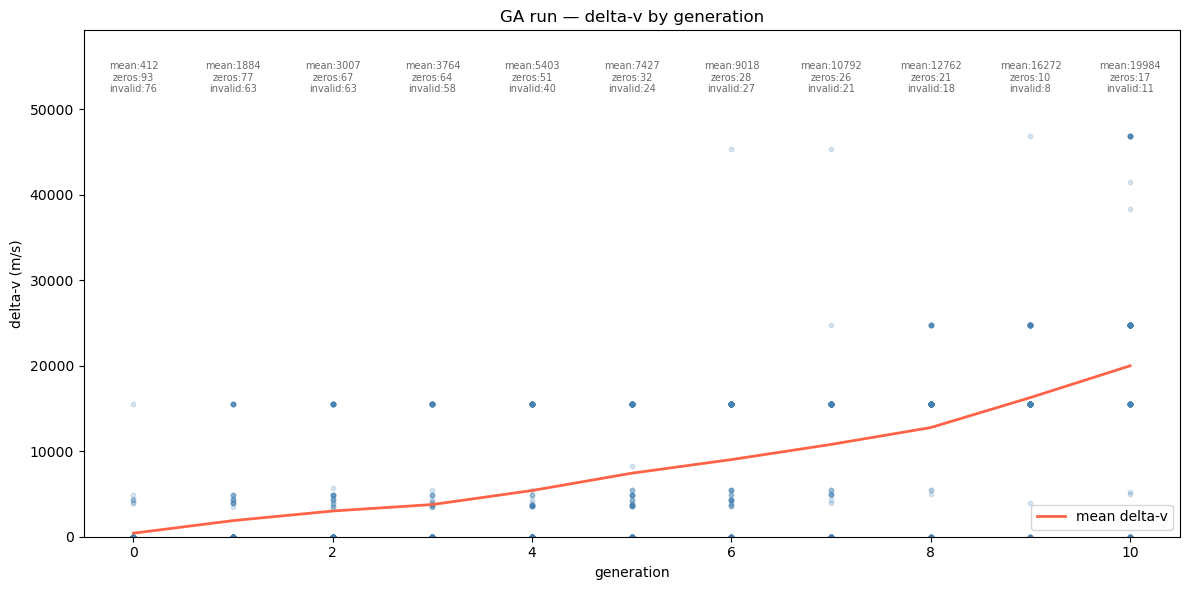

In [3]:
# plot
plot_run(run_dir)

In [8]:
# analyze
from src.analysis import analyze_population

analysis = analyze_population(result, top_n=10, verbose=True)

Top 10 mean score:  46,796 m/s  (2.34x population mean of 19,984 m/s)
Top 10 max score:   46,796 m/s  |  Pop max: 46,796 m/s
Pop zeros: 17.0%  |  Top zeros: 0.0%
Avg stages — top: 1.0  |  pop: 1.1
Top stage dist: 1-stage: 10
Avg parts  — top: 3.0  |  pop: 3.3
Top engine (top 10): turboFanSize2 (10 uses)
Top tank   (top 10): Size3SmallTank (10 uses)
Top pod    (top 10): cupola (10 uses)
